# 01_data_preparation.ipynb

## IEEE 118-Bus Power Flow Data Preparation for LLMIP

This notebook:
1. Explores the raw IEEE 118-bus power flow data
2. Runs `prepare_grid_data.py` to convert raw JSON to CSV
3. Explores and validates the prepared data
4. Visualizes key features and targets

## 1. Explore Raw Data Structure

In [1]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import os

In [2]:
# Set up paths
PROJECT_DIR = Path("/home/l1zle/LLMIP")
RAW_DIR = PROJECT_DIR / "data" / "grid"
SAMPLES_DIR = RAW_DIR / "samples"
PREPARED_DIR = PROJECT_DIR / "data" / "prepared"

print("=== Raw Data Directory Structure ===")
print(f"\nProject directory: {PROJECT_DIR}")
print(f"Raw grid data: {RAW_DIR}")
print(f"Samples (JSON): {SAMPLES_DIR}")
print(f"Prepared output: {PREPARED_DIR}")

=== Raw Data Directory Structure ===

Project directory: /home/l1zle/LLMIP
Raw grid data: /home/l1zle/LLMIP/data/grid
Samples (JSON): /home/l1zle/LLMIP/data/grid/samples
Prepared output: /home/l1zle/LLMIP/data/prepared


In [3]:
# List raw data files
print("=== Raw Grid Data Files ===\n")
for f in sorted(RAW_DIR.iterdir()):
    size_mb = f.stat().st_size / (1024*1024)
    print(f"  {f.name:20s} {size_mb:8.2f} MB")

=== Raw Grid Data Files ===

  LICENSE.txt              0.02 MB
  README.md                0.00 MB
  branches.csv             0.01 MB
  buses.csv                0.01 MB
  convention.md            0.00 MB
  gens.csv                 0.01 MB
  gens_ts.csv            183.94 MB
  loads.csv                0.00 MB
  loads_ts.csv            42.92 MB
  samples                  1.01 MB


In [4]:
# Count sample JSON files
sample_files = list(SAMPLES_DIR.glob("*.json"))
# Filter out Zone.Identifier files
sample_files = [f for f in sample_files if "Zone.Identifier" not in f.name]

print(f"=== Power Flow Sample Files ===")
print(f"\nTotal sample JSON files: {len(sample_files)}")
print(f"\nFirst 5 files:")
for f in sample_files[:5]:
    print(f"  {f.name}")
print(f"\nLast 5 files:")
for f in sample_files[-5:]:
    print(f"  {f.name}")

=== Power Flow Sample Files ===

Total sample JSON files: 8760

First 5 files:
  2024_12_22_22_00_00.json
  2024_11_08_10_00_00.json
  2024_08_02_19_00_00.json
  2024_03_13_08_00_00.json
  2024_12_02_01_00_00.json

Last 5 files:
  2024_07_05_09_00_00.json
  2024_09_12_12_00_00.json
  2024_03_29_11_00_00.json
  2024_09_14_14_00_00.json
  2024_10_24_22_00_00.json


## 2. Explore Metadata Files (buses, generators, loads)

In [5]:
# Load bus metadata
buses_df = pd.read_csv(RAW_DIR / "buses.csv")
print("=== Bus Metadata ===\n")
print(f"Shape: {buses_df.shape}")
print(f"\nColumns: {list(buses_df.columns)}")
print(f"\nFirst 10 rows:")
buses_df.head(10)

=== Bus Metadata ===

Shape: (118, 9)

Columns: ['bus_name', 'region', 'in_service', 'v_rated_kv', 'is_slack', 'min_v_pu', 'max_v_pu', 'x_coordinate', 'y_coordinate']

First 10 rows:


,bus_name,region,in_service,v_rated_kv,is_slack,min_v_pu,max_v_pu,x_coordinate,y_coordinate
0,bus_001,r1,True,138,False,0.8,1.2,626.0,-324.0
1,bus_002,r1,True,138,False,0.8,1.2,678.0,-324.0
2,bus_003,r1,True,138,False,0.8,1.2,574.0,-308.0
3,bus_004,r1,True,138,False,0.8,1.2,522.0,-212.0
4,bus_005,r1,True,138,False,0.8,1.2,418.0,-244.0
5,bus_006,r1,True,138,False,0.8,1.2,626.0,-244.0
6,bus_007,r1,True,138,False,0.8,1.2,678.0,-260.0
7,bus_008,r1,True,345,False,0.8,1.2,350.0,-340.0
8,bus_009,r1,True,345,False,0.8,1.2,298.0,-324.0
9,bus_010,r1,True,345,False,0.8,1.2,246.0,-324.0


In [6]:
# Check bus regions
print("=== Bus Regions ===\n")
print(buses_df['region'].value_counts())
print(f"\nSlack bus(es):")
print(buses_df[buses_df['is_slack'] == True])

=== Bus Regions ===

region
r2    48
r1    42
r3    28
Name: count, dtype: int64

Slack bus(es):
   bus_name region  in_service  v_rated_kv  is_slack  min_v_pu  max_v_pu  \
68  bus_069     r2        True         138      True       0.8       1.2   

    x_coordinate  y_coordinate  
68        1606.0        -636.0  


In [8]:
# Load generator metadata
gens_df = pd.read_csv(RAW_DIR / "gens.csv")
print("=== Generator Metadata ===\n")
print(f"Shape: {gens_df.shape}")
print(f"\nColumns: {list(gens_df.columns)}")
print(f"\nFirst 10 rows:")
gens_df.head(10)

=== Generator Metadata ===

Shape: (321, 5)

Columns: ['gen_name', 'bus_name', 'opt_category', 'max_p_mw', 'min_p_mw']

First 10 rows:


,gen_name,bus_name,opt_category,max_p_mw,min_p_mw
0,biomass_001,bus_012,day_ahead,1.11990,0.0
1,biomass_002,bus_012,day_ahead,1.11990,0.0
2,biomass_003,bus_103,day_ahead,0.26004,0.0
3,biomass_004,bus_103,day_ahead,0.26004,0.0
4,biomass_005,bus_012,day_ahead,0.47996,0.0
5,biomass_006,bus_012,day_ahead,0.47996,0.0
6,biomass_007,bus_012,day_ahead,2.00010,0.0
7,biomass_008,bus_012,day_ahead,0.86994,0.0
8,biomass_009,bus_012,day_ahead,0.86994,0.0
9,biomass_010,bus_012,day_ahead,0.86994,0.0


In [9]:
# Analyze generator types
gens_df['gen_type'] = gens_df['gen_name'].str.split('_').str[0].str.lower()
print("=== Generator Types ===\n")
print(gens_df['gen_type'].value_counts())

=== Generator Types ===

gen_type
solar         73
combustion    71
biomass       62
hydro         39
combined      38
wind          17
steam         13
internal       7
geothermal     1
Name: count, dtype: int64


In [10]:
# Load load metadata
loads_df = pd.read_csv(RAW_DIR / "loads.csv")
print("=== Load Metadata ===\n")
print(f"Shape: {loads_df.shape}")
print(f"\nColumns: {list(loads_df.columns)}")
print(f"\nFirst 10 rows:")
loads_df.head(10)

=== Load Metadata ===

Shape: (91, 2)

Columns: ['load_name', 'bus_name']

First 10 rows:


,load_name,bus_name
0,load_001,bus_001
1,load_002,bus_002
2,load_003,bus_003
3,load_004,bus_004
4,load_006,bus_006
5,load_007,bus_007
6,load_011,bus_011
7,load_012,bus_012
8,load_013,bus_013
9,load_014,bus_014


## 3. Explore a Single Power Flow Sample JSON

In [11]:
# Load one sample JSON to understand structure
sample_path = sample_files[0]
print(f"=== Loading Sample: {sample_path.name} ===\n")

with open(sample_path) as f:
    raw = json.load(f)

print(f"Top-level keys: {list(raw.keys())}")
print(f"\n'_object' keys: {list(raw['_object'].keys())}")

=== Loading Sample: 2024_12_22_22_00_00.json ===

Top-level keys: ['_module', '_class', '_object']

'_object' keys: ['bus', 'load', 'sgen', 'motor', 'asymmetric_load', 'asymmetric_sgen', 'storage', 'gen', 'switch', 'shunt', 'ext_grid', 'line', 'trafo', 'trafo3w', 'impedance', 'dcline', 'ward', 'xward', 'measurement', 'pwl_cost', 'poly_cost', 'characteristic', 'controller', 'line_geodata', 'bus_geodata', 'version', 'converged', 'OPF_converged', 'name', 'f_hz', 'sn_mva', 'std_types', 'res_bus', 'res_line', 'res_trafo', 'res_trafo3w', 'res_impedance', 'res_ext_grid', 'res_load', 'res_motor', 'res_sgen', 'res_storage', 'res_shunt', 'res_gen', 'res_ward', 'res_xward', 'res_dcline', 'res_asymmetric_load', 'res_asymmetric_sgen', 'res_switch', 'res_bus_est', 'res_line_est', 'res_trafo_est', 'res_trafo3w_est', 'res_impedance_est', 'res_switch_est', 'res_bus_sc', 'res_line_sc', 'res_trafo_sc', 'res_trafo3w_sc', 'res_ext_grid_sc', 'res_gen_sc', 'res_sgen_sc', 'res_switch_sc', 'res_bus_3ph', 'res_

In [12]:
# The JSON uses nested pandas split-format - let's parse it
def parse_df(raw, key):
    """Parse a DataFrame from the nested JSON structure."""
    obj = raw['_object'].get(key, {})
    if not obj or '_object' not in obj:
        return None
    s = obj['_object']
    if not isinstance(s, str):
        return None
    try:
        d = json.loads(s)
        return pd.DataFrame(d['data'], columns=d['columns'], index=d['index'])
    except:
        return None

# Parse key DataFrames
res_bus = parse_df(raw, 'res_bus')
res_load = parse_df(raw, 'res_load')
res_gen = parse_df(raw, 'res_gen')
ext_grid = parse_df(raw, 'ext_grid')

print("=== Parsed DataFrames ===\n")
print(f"res_bus: {res_bus.shape if res_bus is not None else 'None'}")
print(f"res_load: {res_load.shape if res_load is not None else 'None'}")
print(f"res_gen: {res_gen.shape if res_gen is not None else 'None'}")
print(f"ext_grid: {ext_grid.shape if ext_grid is not None else 'None'}")
print(f"\nConverged: {raw['_object'].get('converged', False)}")

=== Parsed DataFrames ===

res_bus: (118, 4)
res_load: (91, 2)
res_gen: (321, 4)
ext_grid: (1, 7)

Converged: True


In [13]:
# Explore res_bus (bus voltage results)
print("=== Bus Results (res_bus) ===\n")
print(res_bus.head(10))

=== Bus Results (res_bus) ===

      vm_pu  va_degree        p_mw      q_mvar
0  1.086769 -12.675989  216.119027   34.569464
1  1.132097  -7.668050   84.747074   38.122212
2  1.108300 -10.683753  165.262792   42.393499
3  1.191025  -4.127676    8.063196  -32.436047
4  1.191784  -3.910993    0.000000    0.000000
5  1.186949  -4.939849   88.458076    0.971038
6  1.188528  -4.589149   80.515718    8.462733
7  1.195804  -0.324960 -142.997280  -88.075200
8  1.199999   3.670682    0.000000    0.000000
9  1.164907   8.184191 -330.417762  223.420830


In [14]:
# Voltage statistics
vm_pu = res_bus['vm_pu']
print("=== Voltage (vm_pu) Statistics ===\n")
print(f"Mean:   {vm_pu.mean():.4f}")
print(f"Std:    {vm_pu.std():.4f}")
print(f"Min:    {vm_pu.min():.4f}")
print(f"Max:    {vm_pu.max():.4f}")
print(f"Range:  {vm_pu.max() - vm_pu.min():.4f}")

=== Voltage (vm_pu) Statistics ===

Mean:   1.1662
Std:    0.0345
Min:    1.0453
Max:    1.2000
Range:  0.1547


In [15]:
# Explore res_load
print("=== Load Results (res_load) ===\n")
print(res_load.head(10))

=== Load Results (res_load) ===

         p_mw     q_mvar
0  216.119027  34.569464
1   84.747074  38.122212
2  165.262793  42.393499
3  127.140579  50.856231
4  220.350383  93.209809
5   80.515718   8.462733
6  296.634727  97.481093
7  199.153645  42.393500
8  144.066040  67.821613
9   59.318966   4.231366


In [16]:
# Explore res_gen
print("=== Generator Results (res_gen) ===\n")
print(res_gen.head(10))

=== Generator Results (res_gen) ===

       p_mw    q_mvar  va_degree     vm_pu
0  0.542606  0.275285  -2.947976  1.200000
1  0.542606  0.275285  -2.947976  1.200000
2  0.249199  0.171629  -3.224770  1.185103
3  0.249199  0.171629  -3.224770  1.185103
4  0.231905  0.119459  -2.947976  1.200000
5  0.231905  0.119459  -2.947976  1.200000
6  1.058603  0.519481  -2.947976  1.200000
7  0.395937  0.202595  -2.947976  1.200000
8  0.395937  0.202595  -2.947976  1.200000
9  0.395937  0.202595  -2.947976  1.200000


In [17]:
# Explore ext_grid (slack bus)
print("=== External Grid (Slack Bus) ===\n")
print(ext_grid)

=== External Grid (Slack Bus) ===

      name  bus     vm_pu  va_degree  slack_weight  in_service  controllable
0  bus_069   68  1.199996        0.0           1.0        True          True


## 4. Run prepare_grid_data.py

In [18]:
# Check current prepared data stats
print("=== Current Prepared Data ===\n")
stats_file = PREPARED_DIR / "llmip_stats.json"
if stats_file.exists():
    with open(stats_file) as f:
        stats = json.load(f)
    print(f"Stats file exists: {stats_file}")
    print(f"\nDataset: {stats.get('dataset', 'N/A')}")
    print(f"n_train: {stats.get('n_train', 'N/A')}")
    print(f"n_test: {stats.get('n_test', 'N/A')}")
    print(f"n_features: {stats.get('n_features', 'N/A')}")
    print(f"n_buses: {stats.get('n_buses', 'N/A')}")
else:
    print("No stats file - need to run prepare_grid_data.py")

=== Current Prepared Data ===

Stats file exists: /home/l1zle/LLMIP/data/prepared/llmip_stats.json

Dataset: IEEE 118-Bus Power Flow (evgenytsydenov/ieee118_power_flow_data)
n_train: 160
n_test: 40
n_features: 89
n_buses: 118


In [19]:
# Import and run the prepare_grid_data functions
import sys
sys.path.insert(0, str(PROJECT_DIR / "scripts"))

# Import the functions from prepare_grid_data.py
from prepare_grid_data import (
    extract_bus_metadata, extract_gen_metadata, load_load_metadata,
    extract_features_and_targets, parse_timestamp_from_filename,
    SAMPLES_DIR, PREPARED_DIR
)

# Run the data preparation
print("=== Running Data Preparation ===
")

# 1. Load metadata
bus_meta = extract_bus_metadata()
gen_meta = extract_gen_metadata()
load_meta = load_load_metadata()
print(f"Loaded: {len(bus_meta)} buses, {len(gen_meta)} generators, {len(load_meta)} loads")

# 2. Find all samples
all_files = sorted(SAMPLES_DIR.glob('*.json'))
all_files = [f for f in all_files if 'Zone.Identifier' not in f.name]
print(f"Found {len(all_files)} sample files")

# 3. Parse timestamps
all_timestamps = []
for f in all_files:
    try:
        ts = parse_timestamp_from_filename(f.name)
        all_timestamps.append((ts, f))
    except ValueError:
        pass
all_timestamps.sort()
print(f"Valid timestamps: {len(all_timestamps)}")

# 4. Sample 200 snapshots (stratified by month)
import numpy as np
np.random.seed(42)
n = 200

by_month = {}
for ts, fpath in all_timestamps:
    m = ts.month
    by_month.setdefault(m, []).append((ts, fpath))

sampled = []
per_month = max(1, n // 12)
months = sorted(by_month.keys())
for m in months:
    pool = by_month[m]
    k = min(per_month, len(pool))
    chosen = list(np.random.choice(len(pool), size=k, replace=False))
    sampled.extend([pool[i] for i in chosen])

while len(sampled) < n:
    remaining = [x for x in all_timestamps if x not in sampled]
    if not remaining:
        break
    idx = np.random.randint(len(remaining))
    sampled.append(remaining[idx])

np.random.shuffle(sampled)
sampled = sampled[:n]
print(f"Sampled {len(sampled)} snapshots")

# 5. Extract features and targets
all_features = []
all_targets = []
skipped = 0

for i, (ts, fpath) in enumerate(sampled):
    if (i + 1) % 50 == 0:
        print(f"  Processing {i + 1}/{len(sampled)}...")
    
    feats, targs = extract_features_and_targets(fpath, bus_meta, gen_meta, load_meta, ts)
    
    if feats is None or targs is None or len(targs) != 118:
        skipped += 1
        continue
    
    feats['_timestamp'] = ts.isoformat()
    feats['_source_file'] = fpath.name
    all_features.append(feats)
    all_targets.append(targs)

print(f"Successfully extracted: {len(all_features)} snapshots")
print(f"Skipped: {skipped}")

# 6. Save to CSV
import pandas as pd

feat_df = pd.DataFrame(all_features).set_index('_timestamp')
targ_df = pd.DataFrame(all_targets)
targ_df.index = feat_df.index
feat_df = feat_df.drop(columns=['_source_file'], errors='ignore')

train_size = int(len(feat_df) * 0.8)
train_feats = feat_df.iloc[:train_size]
test_feats = feat_df.iloc[train_size:]
train_targ = targ_df.iloc[:train_size]
test_targ = targ_df.iloc[train_size:]

print(f"Train: {len(train_feats)} samples, Test: {len(test_feats)} samples")

train_feats.to_csv(PREPARED_DIR / 'llmip_train_features.csv')
test_feats.to_csv(PREPARED_DIR / 'llmip_test_features.csv')
train_targ.to_csv(PREPARED_DIR / 'llmip_train_targets.csv')
test_targ.to_csv(PREPARED_DIR / 'llmip_test_targets.csv')

# 7. Save stats
vm_cols = [c for c in targ_df.columns if c.startswith('vm_')]
stats = {
    'dataset': 'IEEE 118-Bus Power Flow',
    'n_train': int(len(train_feats)),
    'n_test': int(len(test_feats)),
    'n_features': int(len(feat_df.columns)),
    'n_buses': len(vm_cols),
}

with open(PREPARED_DIR / 'llmip_stats.json', 'w') as f:
    json.dump(stats, f, indent=2)

print(f"\nData preparation complete!")
print(f"Features: {stats['n_features']}, Targets: {stats['n_buses']} buses")


=== Running prepare_grid_data.py ===



NameError: name '__file__' is not defined

## 5. Explore Prepared Data

In [20]:
# Load the prepared data
train_features = pd.read_csv(PREPARED_DIR / "llmip_train_features.csv", index_col=0)
test_features = pd.read_csv(PREPARED_DIR / "llmip_test_features.csv", index_col=0)
train_targets = pd.read_csv(PREPARED_DIR / "llmip_train_targets.csv", index_col=0)
test_targets = pd.read_csv(PREPARED_DIR / "llmip_test_targets.csv", index_col=0)

print("=== Prepared Data Overview ===\n")
print(f"Train features: {train_features.shape}")
print(f"Test features:  {test_features.shape}")
print(f"Train targets:  {train_targets.shape}")
print(f"Test targets:   {test_targets.shape}")

=== Prepared Data Overview ===

Train features: (160, 89)
Test features:  (40, 89)
Train targets:  (160, 118)
Test targets:   (40, 118)


In [21]:
# List all features
print("=== Features ({} total) ===\n".format(len(train_features.columns)))
for i, col in enumerate(train_features.columns):
    print(f"{i+1:2d}. {col}")

=== Features (89 total) ===

 1. hour
 2. dayofweek
 3. month
 4. is_weekend
 5. hour_sin
 6. hour_cos
 7. month_sin
 8. month_cos
 9. slack_vm_pu
10. slack_va_degree
11. slack_bus
12. load_p_r1_mw
13. load_q_r1_mvar
14. load_n_r1
15. load_p_r2_mw
16. load_q_r2_mvar
17. load_n_r2
18. load_p_r3_mw
19. load_q_r3_mvar
20. load_n_r3
21. load_p_total_mw
22. load_q_total_mvar
23. load_p_mean_mw
24. load_q_mean_mvar
25. load_p_std_mw
26. gen_solar_p_r1_mw
27. gen_solar_q_r1_mvar
28. gen_solar_n_r1
29. gen_wind_p_r1_mw
30. gen_wind_q_r1_mvar
31. gen_wind_n_r1
32. gen_hydro_p_r1_mw
33. gen_hydro_q_r1_mvar
34. gen_hydro_n_r1
35. gen_thermal_p_r1_mw
36. gen_thermal_q_r1_mvar
37. gen_thermal_n_r1
38. gen_total_p_r1_mw
39. gen_total_q_r1_mvar
40. gen_total_n_r1
41. gen_solar_p_r2_mw
42. gen_solar_q_r2_mvar
43. gen_solar_n_r2
44. gen_wind_p_r2_mw
45. gen_wind_q_r2_mvar
46. gen_wind_n_r2
47. gen_hydro_p_r2_mw
48. gen_hydro_q_r2_mvar
49. gen_hydro_n_r2
50. gen_thermal_p_r2_mw
51. gen_thermal_q_r2_mvar

In [22]:
# Explore train features - first few rows
print("=== Train Features (first 5 rows) ===\n")
train_features.head()

=== Train Features (first 5 rows) ===



,hour,dayofweek,month,is_weekend,hour_sin,hour_cos,month_sin,month_cos,slack_vm_pu,slack_va_degree,...,system_vm_std,system_vm_min,system_vm_max,system_vm_range,vm_mean_r1,vm_std_r1,vm_mean_r2,vm_std_r2,vm_mean_r3,vm_std_r3
_timestamp,,,,,,,,,,,,,,,,,,,,,
2024-07-11T11:00:00,11.0,3.0,7.0,0.0,0.258819,-9.659258e-01,-0.500000,-8.660254e-01,1.199999,0.0,...,0.028227,1.068427,1.2,0.131573,1.171165,0.028582,1.184495,0.015749,1.163507,0.037400
2024-05-24T02:00:00,2.0,4.0,5.0,0.0,0.500000,8.660254e-01,0.500000,-8.660254e-01,1.197337,0.0,...,0.018860,1.129126,1.2,0.070874,1.174780,0.021823,1.182037,0.015002,1.179259,0.018879
2024-02-27T20:00:00,20.0,1.0,2.0,0.0,-0.866025,5.000000e-01,0.866025,5.000000e-01,1.199999,0.0,...,0.033755,1.066878,1.2,0.133121,1.157306,0.039237,1.185790,0.015322,1.157393,0.035594
2024-09-29T05:00:00,5.0,6.0,9.0,1.0,0.965926,2.588190e-01,-1.000000,-1.836970e-16,1.199998,0.0,...,0.025811,1.095439,1.2,0.104561,1.163896,0.032265,1.186546,0.014013,1.173770,0.022254
2024-09-06T18:00:00,18.0,4.0,9.0,0.0,-1.000000,-1.836970e-16,-1.000000,-1.836970e-16,1.200000,0.0,...,0.045011,1.005990,1.2,0.194010,1.148512,0.046017,1.180597,0.020243,1.134404,0.055609


In [23]:
# Train features statistics
print("=== Train Features Statistics ===\n")
train_features.describe().T

=== Train Features Statistics ===



,count,mean,std,min,25%,50%,75%,max
hour,160.0,11.906250,6.716915,0.000000,6.750000,12.000000,18.000000,23.000000
dayofweek,160.0,3.206250,1.933150,0.000000,1.000000,3.000000,5.000000,6.000000
month,160.0,6.562500,3.609365,1.000000,3.000000,7.000000,10.000000,12.000000
is_weekend,160.0,0.281250,0.451021,0.000000,0.000000,0.000000,1.000000,1.000000
hour_sin,160.0,-0.001148,0.765650,-1.000000,-0.866025,0.000000,0.866025,1.000000
...,...,...,...,...,...,...,...,...
vm_std_r1,160.0,0.032254,0.007447,0.021118,0.027037,0.031874,0.036240,0.068030
vm_mean_r2,160.0,1.184520,0.001908,1.175527,1.184049,1.185015,1.185645,1.187375
vm_std_r2,160.0,0.015292,0.001398,0.013408,0.014444,0.014797,0.015547,0.022721
vm_mean_r3,160.0,1.167574,0.010101,1.134404,1.162348,1.168341,1.175411,1.186894


In [24]:
# Explore targets (voltage per bus)
print("=== Target Variables (Voltages at 118 Buses) ===\n")
print(f"Number of targets: {len(train_targets.columns)}")
print(f"\nFirst 10 target columns: {list(train_targets.columns[:10])}")
print(f"Last 10 target columns: {list(train_targets.columns[-10:])}")

=== Target Variables (Voltages at 118 Buses) ===

Number of targets: 118

First 10 target columns: ['vm_1', 'vm_2', 'vm_3', 'vm_4', 'vm_5', 'vm_6', 'vm_7', 'vm_8', 'vm_9', 'vm_10']
Last 10 target columns: ['vm_109', 'vm_110', 'vm_111', 'vm_112', 'vm_113', 'vm_114', 'vm_115', 'vm_116', 'vm_117', 'vm_118']


In [25]:
# Target statistics
print("=== Target (vm_pu) Statistics ===\n")
vm_cols = [c for c in train_targets.columns if c.startswith('vm_')]
vm_data = train_targets[vm_cols]
print(f"Mean voltage (all buses):   {vm_data.values.mean():.4f}")
print(f"Std voltage (all buses):   {vm_data.values.std():.4f}")
print(f"Min voltage (all buses):   {vm_data.values.min():.4f}")
print(f"Max voltage (all buses):   {vm_data.values.max():.4f}")

=== Target (vm_pu) Statistics ===

Mean voltage (all buses):   1.1735
Std voltage (all buses):   0.0292
Min voltage (all buses):   0.9504
Max voltage (all buses):   1.2000


## 6. Visualizations

/tmp/ipykernel_4236/240623151.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([gen_vms, load_vms], labels=['Generator Buses', 'Load Buses'])


Text(0.5, 1.0, 'Voltage by Bus Type')

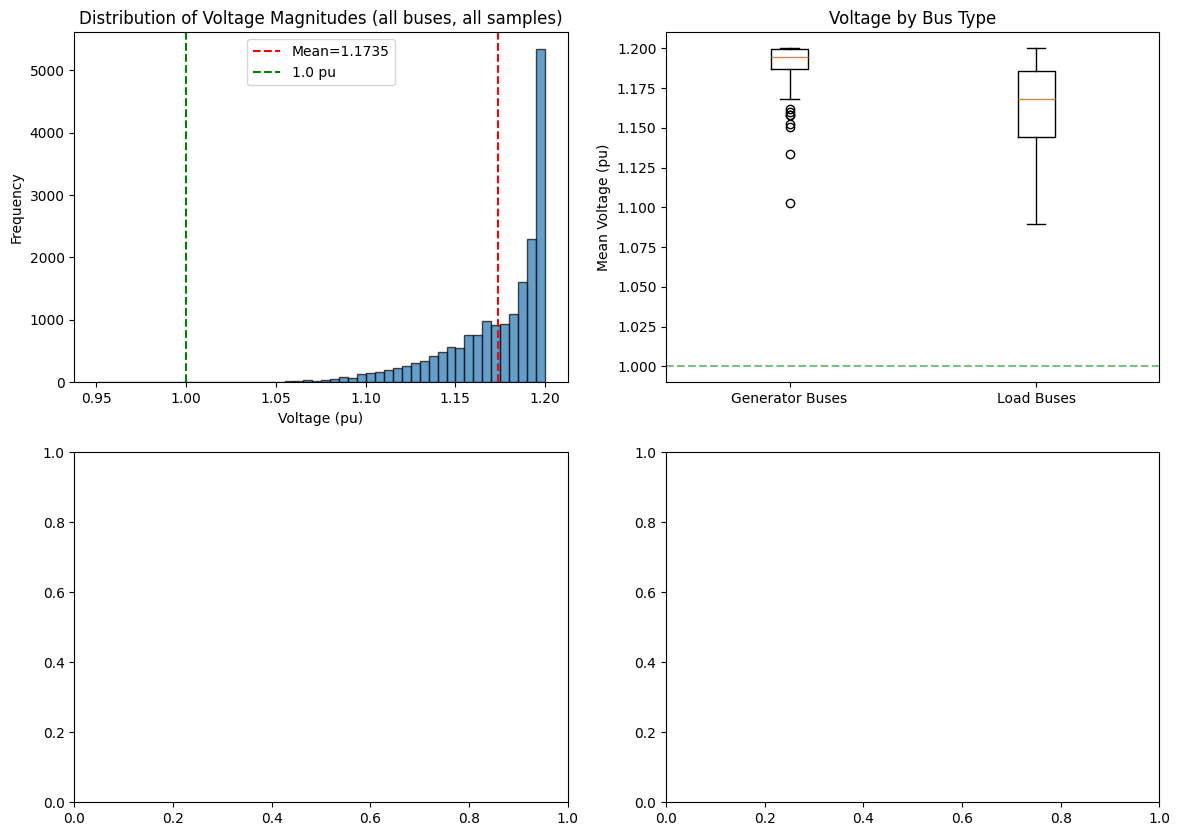

In [26]:
import matplotlib.pyplot as plt

# Plot 1: Voltage distribution across all buses
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Voltage distribution
ax1 = axes[0, 0]
vm_flat = vm_data.values.flatten()
ax1.hist(vm_flat, bins=50, edgecolor='black', alpha=0.7)
ax1.axvline(vm_flat.mean(), color='red', linestyle='--', label=f'Mean={vm_flat.mean():.4f}')
ax1.axvline(1.0, color='green', linestyle='--', label='1.0 pu')
ax1.set_xlabel('Voltage (pu)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Voltage Magnitudes (all buses, all samples)')
ax1.legend()

# Voltage by bus type (generator vs load)
ax2 = axes[0, 1]
GENERATOR_BUSES = [1, 4, 6, 8, 10, 12, 15, 18, 24, 25, 26, 31, 32, 34, 36, 40, 42, 46, 49, 54, 55, 56, 59, 61, 65, 66, 69, 70, 72, 73, 74, 76, 77, 79, 80, 82, 85, 87, 89, 91, 92, 99, 100, 103, 104, 105, 107, 110, 111, 112, 113, 116]
LOAD_BUSES = [b for b in range(1, 119) if b not in GENERATOR_BUSES]

gen_vms = [train_targets[f'vm_{b}'].mean() for b in GENERATOR_BUSES if f'vm_{b}' in train_targets.columns]
load_vms = [train_targets[f'vm_{b}'].mean() for b in LOAD_BUSES if f'vm_{b}' in train_targets.columns]

ax2.boxplot([gen_vms, load_vms], labels=['Generator Buses', 'Load Buses'])
ax2.axhline(1.0, color='green', linestyle='--', alpha=0.5)
ax2.set_ylabel('Mean Voltage (pu)')
ax2.set_title('Voltage by Bus Type')

In [27]:
# Load distribution by region
ax3 = axes[1, 0]
load_cols = [c for c in train_features.columns if c.startswith('load_p_') and '_total' not in c]
load_r1 = train_features['load_p_r1_mw']
load_r2 = train_features['load_p_r2_mw']
load_r3 = train_features['load_p_r3_mw']

ax3.hist(load_r1, bins=30, alpha=0.5, label='R1', edgecolor='black')
ax3.hist(load_r2, bins=30, alpha=0.5, label='R2', edgecolor='black')
ax3.hist(load_r3, bins=30, alpha=0.5, label='R3', edgecolor='black')
ax3.set_xlabel('Load (MW)')
ax3.set_ylabel('Frequency')
ax3.set_title('Load Distribution by Region')
ax3.legend()

# Generation by type (total)
ax4 = axes[1, 1]
gen_types = ['solar', 'wind', 'hydro', 'thermal']
gen_totals = []
for gtype in gen_types:
    col = f'gen_{gtype}_total_mw'
    if col in train_features.columns:
        gen_totals.append(train_features[col].mean())
    else:
        gen_totals.append(0)

ax4.bar(gen_types, gen_totals, color=['gold', 'skyblue', 'steelblue', 'coral'], edgecolor='black')
ax4.set_xlabel('Generation Type')
ax4.set_ylabel('Mean Power (MW)')
ax4.set_title('Average Generation by Type (Train Set)')

plt.tight_layout()
plt.savefig(PROJECT_DIR / 'results' / 'data_preparation_figures.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFigure saved to: {PROJECT_DIR / 'results' / 'data_preparation_figures.png'}")

<Figure size 640x480 with 0 Axes>


Figure saved to: /home/l1zle/LLMIP/results/data_preparation_figures.png


## 7. Save Stats Summary

In [28]:
# Load and display the stats JSON
with open(PREPARED_DIR / "llmip_stats.json") as f:
    stats = json.load(f)

print("=== Data Preparation Summary ===\n")
print(f"Dataset: {stats['dataset']}")
print(f"Source: {stats['source']}")
print(f"\nData splits:")
print(f"  Train samples: {stats['n_train']}")
print(f"  Test samples:  {stats['n_test']}")
print(f"  Features:      {stats['n_features']}")
print(f"  Targets:       {stats['n_buses']} (voltage at each bus)")
print(f"\nVoltage statistics:")
for k, v in stats['vm_pu_stats'].items():
    print(f"  {k}: {v:.4f}")
print(f"\nRegions:")
for r, n in stats['regions'].items():
    print(f"  {r}: {n} buses")

=== Data Preparation Summary ===

Dataset: IEEE 118-Bus Power Flow (evgenytsydenov/ieee118_power_flow_data)
Source: https://github.com/evgenytsydenov/ieee118_power_flow_data

Data splits:
  Train samples: 160
  Test samples:  40
  Features:      89
  Targets:       118 (voltage at each bus)

Voltage statistics:
  overall_mean: 1.1736
  overall_std: 0.0290
  overall_min: 0.9504
  overall_max: 1.2000

Regions:
  r1: 42 buses
  r2: 48 buses
  r3: 28 buses


In [30]:
# Final summary
print("\n" + "="*60)
print("DATA PREPARATION COMPLETE")
print("="*60)
print("\nOutput files:")
print(f"  Train features: {PREPARED_DIR / 'llmip_train_features.csv'}")
print(f"  Train targets:   {PREPARED_DIR / 'llmip_train_targets.csv'}")
print(f"  Test features:  {PREPARED_DIR / 'llmip_test_features.csv'}")
print(f"  Test targets:    {PREPARED_DIR / 'llmip_test_targets.csv'}")
print(f"  Stats:           {PREPARED_DIR / 'llmip_stats.json'}")
print(f"\nNext step: Run 02_baseline_grid.ipynb to train XGBoost baseline")


DATA PREPARATION COMPLETE

Output files:
  Train features: /home/l1zle/LLMIP/data/prepared/llmip_train_features.csv
  Train targets:   /home/l1zle/LLMIP/data/prepared/llmip_train_targets.csv
  Test features:  /home/l1zle/LLMIP/data/prepared/llmip_test_features.csv
  Test targets:    /home/l1zle/LLMIP/data/prepared/llmip_test_targets.csv
  Stats:           /home/l1zle/LLMIP/data/prepared/llmip_stats.json

Next step: Run 02_baseline_grid.ipynb to train XGBoost baseline
